# Universidad del Valle de Guatemala
## CC3092 - Deep Learning

# Laboratorio Semana 4: Seq2Seq Ingles-Espanol desde cero

**Integrantes:** 
- Dulce Ambrosio - 231143
- Angie Vela - 23764
---

## Contexto

Esta semana implementa un modelo Seq2Seq completo para traduccion ingles-espanol con **traducciones naturales en espanol**: el corpus tiene deliberadamente oraciones donde el espanol es mas corto (por elision del sujeto: *she sings well* -> *canta bien*), mas largo (por perifrasis verbales: *the cat sleeps* -> *el gato esta durmiendo*), o del mismo largo. Esa asimetria de largo es exactamente la razon de ser de la arquitectura Encoder-Decoder.

Pipeline:
```
oracion_EN -> [E_enc] -> [Encoder LSTM] -> c = h_T^enc
                                            |
<SOS>+oracion_ES -> [E_dec] -> [Decoder LSTM] -> [W_out+softmax] -> prediccion
```

## Reglas

- Use unicamente PyTorch. No use `nn.LSTM`, `nn.Embedding`, `nn.Linear` ni capas de alto nivel.
- El backward debe ser manual*. No use `loss.backward()`.
- No modifique los pesos iniciales ni el corpus.
- La celda final calcula su nota automatica sobre los **60 puntos** de codigo.

In [1]:
import torch
import torch.nn.functional as F
import hashlib, numpy as np, random, time
from collections import Counter
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cpu


---
## Bloque 0: Corpus, vocabularios y pesos iniciales (dado, no modificar)

In [2]:
CORPUS_COMPLETO = [
    ("i love you", "te amo"),
    ("i drink water", "bebo agua"),
    ("i read the news", "leo las noticias"),
    ("i write a book", "escribo un libro"),
    ("i hear music", "escucho musica"),
    ("i call my mother", "llamo a mi madre"),
    ("i take a photo", "tomo una foto"),
    ("i finish my work", "termino mi trabajo"),
    ("i open the book", "abro el libro"),
    ("i run every morning", "corro cada manana"),
    ("i learn spanish", "aprendo espanol"),
    ("i like coffee", "me gusta el cafe"),
    ("i work every day", "trabajo todos los dias"),
    ("i buy fresh bread", "compro pan fresco"),
    ("she reads books", "lee libros"),
    ("she sings well", "canta bien"),
    ("she cooks dinner", "cocina la cena"),
    ("she opens the door", "abre la puerta"),
    ("she sleeps early", "duerme temprano"),
    ("she buys flowers", "compra flores"),
    ("she draws pictures", "dibuja imagenes"),
    ("she visits her friend", "visita a su amiga"),
    ("she teaches math", "ensena matematica"),
    ("she paints a picture", "pinta un cuadro"),
    ("she writes a poem", "escribe un poema"),
    ("she enjoys the music", "disfruta la musica"),
    ("she prepares the meal", "prepara la comida"),
    ("he runs fast", "corre rapido"),
    ("he writes a letter", "escribe una carta"),
    ("he closes the window", "cierra la ventana"),
    ("he eats an apple", "come una manzana"),
    ("he drives a car", "conduce un carro"),
    ("he fixes the bike", "arregla la bicicleta"),
    ("he plays the guitar", "toca la guitarra"),
    ("he studies history", "estudia historia"),
    ("he answers the phone", "contesta el telefono"),
    ("he repairs the chair", "repara la silla"),
    ("he teaches the class", "ensena la clase"),
    ("we eat bread", "comemos pan"),
    ("we walk together", "caminamos juntos"),
    ("we leave early", "salimos temprano"),
    ("we cook together", "cocinamos juntos"),
    ("we swim in the sea", "nadamos en el mar"),
    ("we watch the stars", "miramos las estrellas"),
    ("we visit the museum", "visitamos el museo"),
    ("we celebrate together", "celebramos juntos"),
    ("we enjoy the summer", "disfrutamos el verano"),
    ("they play soccer", "juegan futbol"),
    ("they arrive late", "llegan tarde"),
    ("they build a house", "construyen una casa"),
    ("they clean the room", "limpian el cuarto"),
    ("they watch the movie", "ven la pelicula"),
    ("they travel by train", "viajan en tren"),
    ("they eat together", "comen juntos"),
    ("they sing a song", "cantan una cancion"),
    ("they dance all night", "bailan toda la noche"),
    ("they plant the seeds", "plantan las semillas"),
    ("they clean the street", "limpian la calle"),
    ("the cat sleeps", "el gato esta durmiendo"),
    ("the dog barks", "el perro esta ladrando"),
    ("the bird flies", "el pajaro esta volando"),
    ("the sun shines", "el sol esta brillando"),
    ("the fish swims", "el pez esta nadando"),
    ("the baby laughs", "el bebe esta riendo"),
    ("the teacher explains", "el profesor esta explicando"),
    ("the rain falls", "la lluvia esta cayendo"),
    ("the moon rises", "la luna esta subiendo"),
    ("the wind blows", "el viento esta soplando"),
    ("the fire burns", "el fuego esta ardiendo"),
    ("the clock ticks", "el reloj esta sonando"),
    ("we study english", "estudiamos ingles"),
    ("we paint the wall", "pintamos la pared"),
    ("we drink hot tea", "bebemos te caliente"),
    ("we meet every week", "nos reunimos cada semana"),
    ("the cat drinks milk", "el gato bebe leche"),
    ("the child plays", "el nino juega"),
    ("he reads the newspaper", "lee el periodico"),
    ("she closes her eyes", "cierra los ojos"),
]

# Split 75/25 reproducible
random.seed(42)
indices = list(range(len(CORPUS_COMPLETO)))
random.shuffle(indices)
n_train = int(len(CORPUS_COMPLETO) * 0.75)
TRAIN_DATA = [CORPUS_COMPLETO[i] for i in indices[:n_train]]
TEST_DATA  = [CORPUS_COMPLETO[i] for i in indices[n_train:]]
print(f'Train: {len(TRAIN_DATA)} pares, Test: {len(TEST_DATA)} pares')
print(f'Primer par de entrenamiento: {TRAIN_DATA[0]}')
# Verificar distribucion de largos
diffs = [len(tgt.split())-len(src.split()) for src,tgt in CORPUS_COMPLETO]
from collections import Counter
print('Diferencia largo ES - largo EN:', dict(sorted(Counter(diffs).items())))


Train: 58 pares, Test: 20 pares
Primer par de entrenamiento: ('they play soccer', 'juegan futbol')
Diferencia largo ES - largo EN: {-1: 57, 0: 8, 1: 13}


In [3]:
SOS, EOS, PAD, UNK = '<SOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL = [PAD, UNK, SOS, EOS]

def build_vocab(sentences):
    words = set()
    for s in sentences: words.update(s.lower().split())
    vocab = SPECIAL + sorted(words)
    w2i = {w: i for i, w in enumerate(vocab)}
    i2w = {i: w for w, i in w2i.items()}
    return vocab, w2i, i2w

src_vocab, src_w2i, src_i2w = build_vocab([p[0] for p in CORPUS_COMPLETO])
tgt_vocab, tgt_w2i, tgt_i2w = build_vocab([p[1] for p in CORPUS_COMPLETO])
src_V = len(src_vocab); tgt_V = len(tgt_vocab)
print(f'Vocabulario EN: {src_V} palabras')
print(f'Vocabulario ES: {tgt_V} palabras')

def tokenize_src(sentence):
    return [src_w2i.get(w.lower(), src_w2i[UNK]) for w in sentence.split()]

def tokenize_tgt(sentence):
    return ([tgt_w2i[SOS]] +
            [tgt_w2i.get(w.lower(), tgt_w2i[UNK]) for w in sentence.split()] +
            [tgt_w2i[EOS]])

Vocabulario EN: 158 palabras
Vocabulario ES: 163 palabras


In [4]:
d_emb = 16; d_hid = 32
torch.manual_seed(42)
E_enc = torch.randn(d_emb, src_V) * 0.1
E_dec = torch.randn(d_emb, tgt_V) * 0.1
Wf_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_enc=torch.zeros(d_hid)
Wi_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_enc=torch.zeros(d_hid)
Wc_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_enc=torch.zeros(d_hid)
Wo_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_enc=torch.zeros(d_hid)
Wf_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_dec=torch.zeros(d_hid)
Wi_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_dec=torch.zeros(d_hid)
Wc_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_dec=torch.zeros(d_hid)
Wo_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_dec=torch.zeros(d_hid)
W_out = torch.randn(tgt_V, d_hid) * 0.1; b_out = torch.zeros(tgt_V)
alpha = 0.01
print(f'E_enc: {E_enc.shape}, Wf_enc: {Wf_enc.shape}, W_out: {W_out.shape}')

E_enc: torch.Size([16, 158]), Wf_enc: torch.Size([32, 48]), W_out: torch.Size([163, 32])


---
## Bloque 1: Lookup de embeddings

Implemente `get_embedding` que selecciona la columna `idx` de la matriz `E`:

$$\mathbf{e} = E[:, \text{idx}]$$

El backward de esta operacion acumula gradiente **solo** en la columna `idx`: las palabras que no aparecen en la secuencia no reciben actualizacion.

Implemente tambien `get_embedding_batch` para una lista de indices.

In [5]:
def get_embedding(E, idx):
    """
    Selecciona la columna idx de E. Retorna tensor (d_emb,).

    E tiene forma (d_emb, V): cada COLUMNA es el vector de una palabra.
    Por eso el lookup es E[:, idx] y no una multiplicacion por un one-hot:
    el producto E @ v_one_hot da exactamente la misma columna, pero cuesta
    O(d_emb * V) en lugar de O(d_emb). El lookup es la version eficiente.

    Consecuencia para el backward: como solo se usa esta columna, el
    gradiente unicamente se acumula en dE[:, idx]; el resto de columnas
    del vocabulario queda intacto en esa actualizacion.
    """
    return E[:, idx]


def get_embedding_batch(E, indices):
    """Retorna lista de embeddings para una lista de indices."""
    return [get_embedding(E, idx) for idx in indices]


emb_test = get_embedding(E_enc, 0)
print(f'Embedding token 0: {emb_test.shape if emb_test is not None else None}')

Embedding token 0: torch.Size([16])


---
## Bloque 2: Celda LSTM y forward del encoder

Implemente `lstm_cell` con las cinco ecuaciones del LSTM.  
Luego implemente `encoder_forward` que lee la secuencia de entrada completa y retorna:
- `context_h`: hidden state final $h_T^{enc}$ (vector de contexto)
- `context_c`: cell state final $c_T^{enc}$
- `enc_caches`: lista de caches de cada paso (necesarios para el backward)

Guarde el indice del embedding en cada cache con la clave `'emb_idx'`.

**Importante:** el par de verificacion es `TRAIN_DATA[0] = ('they play soccer', 'juegan futbol')`. El encoder lee 3 tokens en ingles y el decoder genera 2 tokens en espanol mas EOS. Esta asimetria es intencional y debe funcionar sin cambios en el codigo.

In [ ]:
def lstm_cell(h, c, x, Wf, bf, Wi, bi, Wc, bc, Wo, bo):
    """
    Un paso de tiempo LSTM.
    Retorna (h_new, c_new, cache).
    El cache debe contener: concat, h_prev, c_prev, f, i, ct, c_t, o, h_t

    Ecuaciones (con concat = [h_{t-1} ; x_t] de dimension d_hid + d_emb):
        f_t  = sigmoid(Wf @ concat + bf)      olvido: cuanto del estado viejo se conserva
        i_t  = sigmoid(Wi @ concat + bi)      entrada: cuanto del candidato se escribe
        ct_t = tanh   (Wc @ concat + bc)      candidato de memoria
        c_t  = f_t * c_{t-1} + i_t * ct_t     nuevo estado de celda
        o_t  = sigmoid(Wo @ concat + bo)      salida: cuanto de la memoria se expone
        h_t  = o_t * tanh(c_t)                nuevo hidden state
    """
    concat = torch.cat([h, x])              # (d_hid + d_emb,)

    f  = torch.sigmoid(Wf @ concat + bf)    # puerta de olvido
    i  = torch.sigmoid(Wi @ concat + bi)    # puerta de entrada
    ct = torch.tanh(Wc @ concat + bc)       # candidato \tilde{c}_t
    c_t = f * c + i * ct                    # estado de celda actualizado
    o  = torch.sigmoid(Wo @ concat + bo)    # puerta de salida
    h_t = o * torch.tanh(c_t)               # hidden state

    # Todo lo que el backward va a necesitar se guarda aqui, no hay que recalcular
    cache = {
        'concat': concat, 'h_prev': h, 'c_prev': c,
        'f': f, 'i': i, 'ct': ct, 'c_t': c_t, 'o': o, 'h_t': h_t,
    }
    return h_t, c_t, cache


def encoder_forward(src_indices, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc,
                    Wc_enc, bc_enc, Wo_enc, bo_enc):
    """
    Forward del encoder. Retorna (context_h, context_c, enc_caches).

    Corre exactamente len(src_indices) pasos: el largo de la entrada no esta
    atado al largo de la salida. El ultimo hidden state h_T es el vector de
    contexto c que resume toda la oracion en ingles.
    """
    h = torch.zeros(d_hid); c = torch.zeros(d_hid); caches = []

    for idx in src_indices:
        x = get_embedding(E_enc, idx)                       # lookup del embedding
        h, c, cache = lstm_cell(h, c, x,
                                Wf_enc, bf_enc, Wi_enc, bi_enc,
                                Wc_enc, bc_enc, Wo_enc, bo_enc)
        cache['emb_idx'] = idx      # se guarda el indice para el backward de E_enc
        caches.append(cache)

    return h, c, caches   # h = h_T^enc = vector de contexto


# Verificar con TRAIN_DATA[0]: 'they play soccer' -> 'juegan futbol'
src_test = tokenize_src(TRAIN_DATA[0][0])
context_h, context_c, enc_caches = encoder_forward(
    src_test, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc, Wc_enc, bc_enc, Wo_enc, bo_enc)
print(f'Entrada EN: {TRAIN_DATA[0][0]} -> tokens: {src_test}')
print(f'context_h forma: {context_h.shape if context_h is not None else None}')
print(f'Caches encoder: {len(enc_caches)} (uno por token de entrada)')

Entrada EN: they play soccer -> tokens: [138, 103, 122]
context_h forma: torch.Size([32])
Caches encoder: 3 (uno por token de entrada)


In [7]:
# VERIFICACION BLOQUE 2
_H = 'a1c22d089ecfb52bdae47e330603a46d492f9318dc6b2071956ef1a9c406eeec'
try:
    assert context_h is not None and context_h.shape == (d_hid,), \
        f'context_h debe ser ({d_hid},), obtenida {getattr(context_h,"shape",None)}'
    assert len(enc_caches) == len(src_test), \
        f'enc_caches debe tener {len(src_test)} entradas, tiene {len(enc_caches)}'
    assert _hash_tensor(context_h) == _H, 'context_h incorrecto.'
    _resultados['b2'] = True; print('BLOQUE 2: CORRECTO')
except AssertionError as e:
    _resultados['b2'] = False; print(f'BLOQUE 2: INCORRECTO\n  {e}')

BLOQUE 2: CORRECTO


---
## Bloque 3: Forward del decoder con teacher forcing

Implemente `decoder_forward` con teacher forcing.

El par de verificacion tiene **largo asimetrico**: el encoder leyo 3 tokens (*they play soccer*) y el decoder debe generar 2 tokens en espanol (*juegan futbol*) mas EOS. Su implementacion debe manejar cualquier combinacion de largos sin codigo especial.

- Input del decoder: `[SOS, juegan]` (largo 2)
- Target del decoder: `[juegan, futbol, EOS]` (largo 3)
- El decoder corre exactamente `len(dec_input_indices)` pasos

In [8]:
def decoder_forward(dec_input_indices, dec_target_indices, context_h, context_c,
                    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec,
                    Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out):
    """
    Forward decoder con teacher forcing.
    Retorna (logits_list, dec_caches)
    logits_list: lista de tensores (tgt_V,), uno por paso

    Teacher forcing: en el paso s la entrada del decoder es la palabra
    CORRECTA del paso anterior (dec_input_indices[s]), no la prediccion del
    modelo. Eso desacopla los errores entre pasos y acelera la convergencia.

    El estado inicial es el vector de contexto del encoder: ahi es donde el
    decoder "recibe" toda la informacion de la oracion en ingles. Como el loop
    itera sobre dec_input_indices, el numero de pasos S es independiente de T.
    """
    h = context_h.clone(); c = context_c.clone()
    caches = []; logits_list = []

    for idx in dec_input_indices:
        x = get_embedding(E_dec, idx)                       # embedding del token guia
        h, c, cache = lstm_cell(h, c, x,
                                Wf_dec, bf_dec, Wi_dec, bi_dec,
                                Wc_dec, bc_dec, Wo_dec, bo_dec)
        cache['emb_idx'] = idx
        caches.append(cache)
        logits_list.append(W_out @ h + b_out)   # proyeccion a vocabulario (tgt_V,)

    return logits_list, caches


tgt_tokens_full = tokenize_tgt(TRAIN_DATA[0][1])
dec_input_idx  = tgt_tokens_full[:-1]   # [SOS, juegan, futbol]
dec_target_idx = tgt_tokens_full[1:]    # [juegan, futbol, EOS]
print(f'Salida ES: {TRAIN_DATA[0][1]} -> tokens: {tgt_tokens_full}')
print(f'Input decoder:  {dec_input_idx}  (largo {len(dec_input_idx)})')
print(f'Target decoder: {dec_target_idx} (largo {len(dec_target_idx)})')
print(f'Largo EN ({len(src_test)}) != Largo ES ({len(dec_target_idx)}): asimetria correcta')
logits_list, dec_caches = decoder_forward(
    dec_input_idx, dec_target_idx, context_h, context_c,
    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec, Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out)
print(f'Pasos del decoder: {len(logits_list)}')
print(f'Forma de cada logit: {logits_list[0].shape if logits_list else None}')

Salida ES: juegan futbol -> tokens: [2, 81, 73, 3]
Input decoder:  [2, 81, 73]  (largo 3)
Target decoder: [81, 73, 3] (largo 3)
Largo EN (3) != Largo ES (3): asimetria correcta
Pasos del decoder: 3
Forma de cada logit: torch.Size([163])


---
## Bloque 4: Perdida de entropia cruzada categorica

$$L = \frac{1}{S} \sum_{s=1}^{S} \left(-\log \hat{y}_s[w_s^*]\right)$$

Use `F.log_softmax` para estabilidad numerica. Resultado: tensor escalar.

In [9]:
def compute_loss(logits_list, target_indices):
    """
    Entropia cruzada categorica promedio sobre la secuencia.
    Retorna tensor escalar.

    L = (1/S) * sum_s ( -log softmax(z_s)[w_s*] )

    Se usa log_softmax en lugar de log(softmax(...)) por estabilidad numerica:
    log_softmax resta el maximo internamente y evita overflow de exp().
    El promedio (y no la suma) hace que oraciones largas y cortas contribuyan
    con una magnitud comparable de gradiente.
    """
    total = 0.0
    for z, tgt_idx in zip(logits_list, target_indices):
        log_probs = F.log_softmax(z, dim=0)     # (tgt_V,)
        total = total + (-log_probs[tgt_idx])   # perdida del paso s
    return total / len(logits_list)


S = len(dec_target_idx)
loss_mean = compute_loss(logits_list, dec_target_idx)
print(f'S (largo secuencia decodificada): {S}')
print(f'loss_mean: {loss_mean.item() if loss_mean is not None else None:.4f}')

S (largo secuencia decodificada): 3
loss_mean: 5.0933


In [10]:
# VERIFICACION BLOQUE 4
try:
    assert loss_mean is not None, 'loss_mean no definido.'
    assert abs(loss_mean.item() - 5.093276) < 1e-3, \
        f'loss_mean incorrecto: {loss_mean.item():.6f}, esperado ~5.093'
    _resultados['b4'] = True; print('BLOQUE 4: CORRECTO')
except AssertionError as e:
    _resultados['b4'] = False; print(f'BLOQUE 4: INCORRECTO\n  {e}')

BLOQUE 4: CORRECTO


---
## BACKWARD PASS

---

## Bloque 5: Backward del decoder

BPTT sobre los $S$ pasos del decoder en orden inverso.

En cada paso $s$:
1. $\frac{\partial L}{\partial z_s} = \frac{1}{S}\left(\hat{y}_s - \mathbf{1}_{w_s^*}\right)$
2. Acumular en `dW_out`, `db_out`
3. Gradiente hacia $h_s^{dec}$: suma de `W_out.T @ dL_dz` y el gradiente del paso siguiente
4. BPTT de la celda LSTM
5. Acumular en pesos del decoder y en `dE_dec[:, emb_idx]`
6. Propagar `dL_dh_next` y `dL_dc_next`

Al salir del loop: `dL_dh_context = dL_dh_dec_next` inicia el backward del encoder.

In [ ]:
def lstm_backward(cache, dL_dh, dL_dc_next, Wf, Wi, Wc, Wo):
    """
    BPTT de un paso de la celda LSTM (se reutiliza en el decoder, el encoder
    y el bloque 7; asi el backward queda escrito una sola vez y podemos reutilizar codigo).

    Entradas:
      dL_dh      : gradiente total que llega a h_t (salida + paso siguiente)
      dL_dc_next : gradiente que llega a c_t desde el paso siguiente

    Derivadas usadas:
      h_t = o * tanh(c_t)   ->  dL/do = dL/dh * tanh(c_t)
                                dL/dc_t = dL/dh * o * (1 - tanh(c_t)^2) + dL_dc_next
      c_t = f*c_prev + i*ct ->  dL/df = dL/dc_t * c_prev
                                dL/di = dL/dc_t * ct
                                dL/dct = dL/dc_t * i
                                dL/dc_prev = dL/dc_t * f
      sigmoid: da = dg * g * (1-g)      tanh: da = dg * (1 - g^2)
      preactivacion a = W @ concat + b  ->  dW = outer(da, concat), db = da
      dconcat = suma de W.T @ da de las cuatro puertas; se parte en
      dh_prev (primeras d_hid componentes) y dx (las d_emb restantes).
    """
    f, i, ct, o = cache['f'], cache['i'], cache['ct'], cache['o']
    c_t, c_prev, concat = cache['c_t'], cache['c_prev'], cache['concat']

    tanh_c = torch.tanh(c_t)

    dL_do  = dL_dh * tanh_c
    dL_dc  = dL_dh * o * (1 - tanh_c ** 2) + dL_dc_next   # gradiente total en c_t

    dL_df  = dL_dc * c_prev
    dL_di  = dL_dc * ct
    dL_dct = dL_dc * i
    dL_dc_prev = dL_dc * f          # el "carrusel constante" de la memoria

    # Gradientes en las preactivaciones (antes de sigmoid / tanh)
    da_f = dL_df  * f * (1 - f)
    da_i = dL_di  * i * (1 - i)
    da_o = dL_do  * o * (1 - o)
    da_c = dL_dct * (1 - ct ** 2)

    dWf, dbf = torch.outer(da_f, concat), da_f
    dWi, dbi = torch.outer(da_i, concat), da_i
    dWc, dbc = torch.outer(da_c, concat), da_c
    dWo, dbo = torch.outer(da_o, concat), da_o

    dconcat = Wf.T @ da_f + Wi.T @ da_i + Wc.T @ da_c + Wo.T @ da_o
    dL_dh_prev = dconcat[:d_hid]    # hacia el paso anterior
    dL_dx      = dconcat[d_hid:]    # hacia el embedding de este paso

    return (dWf, dbf, dWi, dbi, dWc, dbc, dWo, dbo,
            dL_dh_prev, dL_dc_prev, dL_dx)


dWf_dec=torch.zeros_like(Wf_dec); dbf_dec=torch.zeros_like(bf_dec)
dWi_dec=torch.zeros_like(Wi_dec); dbi_dec=torch.zeros_like(bi_dec)
dWc_dec=torch.zeros_like(Wc_dec); dbc_dec=torch.zeros_like(bc_dec)
dWo_dec=torch.zeros_like(Wo_dec); dbo_dec=torch.zeros_like(bo_dec)
dW_out =torch.zeros_like(W_out);  db_out =torch.zeros_like(b_out)
dE_dec =torch.zeros_like(E_dec)
dL_dh_dec_next = torch.zeros(d_hid)
dL_dc_dec_next = torch.zeros(d_hid)

for s in reversed(range(S)):
    cc = dec_caches[s]
    z  = logits_list[s]
    tgt_idx = dec_target_idx[s]

    # 1) Gradiente en los logits: (y_hat - one_hot) / S  (softmax + CE combinados)
    y_hat = torch.softmax(z, dim=0).clone()
    y_hat[tgt_idx] -= 1.0
    dL_dz = y_hat / S                     # el 1/S viene del promedio de la perdida

    # 2) Capa de salida z = W_out @ h + b_out
    dW_out += torch.outer(dL_dz, cc['h_t'])
    db_out += dL_dz

    # 3) Gradiente hacia h_s: el de la salida de este paso + el del paso siguiente
    dL_dh = W_out.T @ dL_dz + dL_dh_dec_next

    # 4) BPTT de la celda LSTM del decoder
    (gWf, gbf, gWi, gbi, gWc, gbc, gWo, gbo,
     dL_dh_prev, dL_dc_prev, dL_dx) = lstm_backward(
        cc, dL_dh, dL_dc_dec_next, Wf_dec, Wi_dec, Wc_dec, Wo_dec)

    # 5) Acumular en los pesos del decoder y en la columna del embedding usado
    dWf_dec += gWf; dbf_dec += gbf
    dWi_dec += gWi; dbi_dec += gbi
    dWc_dec += gWc; dbc_dec += gbc
    dWo_dec += gWo; dbo_dec += gbo
    dE_dec[:, cc['emb_idx']] += dL_dx

    # 6) Propagar hacia el paso anterior del decoder
    dL_dh_dec_next = dL_dh_prev
    dL_dc_dec_next = dL_dc_prev

# Al salir del loop, estos gradientes corresponden a h_0^dec = c (vector de contexto)
dL_dh_context = dL_dh_dec_next.clone()
dL_dc_context = dL_dc_dec_next.clone()
print(f'dWf_dec forma: {dWf_dec.shape}')
print(f'dL_dh_context forma: {dL_dh_context.shape}')

dWf_dec forma: torch.Size([32, 48])
dL_dh_context forma: torch.Size([32])


In [12]:
# VERIFICACION BLOQUE 5
_H = '91fcfa6f4bce42112eeec9128a60f328dcf657eb74249caafef27b17fc772547'
try:
    assert _hash_tensor(dWf_dec) == _H, 'dWf_dec incorrecto.'
    _resultados['b5'] = True; print('BLOQUE 5: CORRECTO')
except AssertionError as e:
    _resultados['b5'] = False; print(f'BLOQUE 5: INCORRECTO\n  {e}')

BLOQUE 5: CORRECTO


---
## Bloque 6: Backward del encoder

`dL_dh_context` entra al encoder como gradiente de $h_T^{enc}$.  
Aplique BPTT sobre los $T$ pasos del encoder en orden inverso,  
acumulando gradientes en los pesos del encoder y en `dE_enc[:, emb_idx]`.

In [13]:
dWf_enc=torch.zeros_like(Wf_enc); dbf_enc=torch.zeros_like(bf_enc)
dWi_enc=torch.zeros_like(Wi_enc); dbi_enc=torch.zeros_like(bi_enc)
dWc_enc=torch.zeros_like(Wc_enc); dbc_enc=torch.zeros_like(bc_enc)
dWo_enc=torch.zeros_like(Wo_enc); dbo_enc=torch.zeros_like(bo_enc)
dE_enc =torch.zeros_like(E_enc)
dL_dh_enc_next = dL_dh_context.clone()   # el gradiente entra por h_T^enc = c
dL_dc_enc_next = dL_dc_context.clone()   # y por c_T^enc

# BPTT del encoder: T pasos hacia atras. Aqui el encoder NO tiene perdida propia,
# todo su gradiente proviene del vector de contexto que uso el decoder.
for t in reversed(range(len(enc_caches))):
    cc = enc_caches[t]

    (gWf, gbf, gWi, gbi, gWc, gbc, gWo, gbo,
     dL_dh_prev, dL_dc_prev, dL_dx) = lstm_backward(
        cc, dL_dh_enc_next, dL_dc_enc_next, Wf_enc, Wi_enc, Wc_enc, Wo_enc)

    dWf_enc += gWf; dbf_enc += gbf
    dWi_enc += gWi; dbi_enc += gbi
    dWc_enc += gWc; dbc_enc += gbc
    dWo_enc += gWo; dbo_enc += gbo
    dE_enc[:, cc['emb_idx']] += dL_dx    # solo la columna de la palabra vista

    dL_dh_enc_next = dL_dh_prev
    dL_dc_enc_next = dL_dc_prev

print(f'dWf_enc forma: {dWf_enc.shape}')
print(f'dE_enc forma:  {dE_enc.shape}')

dWf_enc forma: torch.Size([32, 48])
dE_enc forma:  torch.Size([16, 158])


In [14]:
# VERIFICACION BLOQUE 6
_HASHES_B6 = {
    'dWf_enc': '3fafa04007ed020a0ccd8969f95aa4ba130aafd7aa4b60a7efbbcbc73593f2c5',
    'dE_enc':  '56bb53461e329a75e94c28b9cc4599d9461b9302793853a5d698b8905f6df7d5',
}
try:
    assert _hash_tensor(dWf_enc) == _HASHES_B6['dWf_enc'], 'dWf_enc incorrecto.'
    assert _hash_tensor(dE_enc)  == _HASHES_B6['dE_enc'],  'dE_enc incorrecto.'
    _resultados['b6'] = True; print('BLOQUE 6: CORRECTO')
except AssertionError as e:
    _resultados['b6'] = False; print(f'BLOQUE 6: INCORRECTO\n  {e}')

BLOQUE 6: CORRECTO


---
## Bloque 7: Gradientes de embeddings - version completa vs diccionario

Ya tiene `dE_enc` completa (misma forma que `E_enc`, ceros en columnas no usadas).  
Implemente la version eficiente con diccionario: guarda solo los gradientes de las columnas que aparecieron en la secuencia.  
Mida el tiempo de actualizacion con ambas versiones sobre 1000 repeticiones y compare.

In [15]:
def compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                    Wf_enc, Wi_enc, Wc_enc, Wo_enc):
    """
    Gradiente de embeddings del encoder usando diccionario.
    Retorna dict {idx: grad_tensor (d_emb,)}

    Es el MISMO BPTT del Bloque 6, pero en lugar de reservar una matriz
    (d_emb, src_V) casi toda en ceros, solo se guardan las columnas que
    realmente aparecieron en la oracion. Con 3-5 tokens por oracion y 158
    palabras de vocabulario, se toca menos del 4% de la matriz.
    """
    dE_dict = {}
    dh_next = dL_dh_context.clone()
    dc_next = dL_dc_context.clone()

    for t in reversed(range(len(enc_caches))):
        cc = enc_caches[t]

        (_, _, _, _, _, _, _, _,
         dL_dh_prev, dL_dc_prev, dL_dx) = lstm_backward(
            cc, dh_next, dc_next, Wf_enc, Wi_enc, Wc_enc, Wo_enc)

        idx = cc['emb_idx']
        # Acumular (una palabra puede repetirse dentro de la misma oracion)
        if idx in dE_dict:
            dE_dict[idx] = dE_dict[idx] + dL_dx
        else:
            dE_dict[idx] = dL_dx.clone()

        dh_next = dL_dh_prev
        dc_next = dL_dc_prev

    return dE_dict


N_rep = 1000
t0 = time.time()
for _ in range(N_rep): _ = E_enc - alpha * dE_enc
t_full = (time.time()-t0)/N_rep*1e6

dE_dict = compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                           Wf_enc, Wi_enc, Wc_enc, Wo_enc)
t0 = time.time()
for _ in range(N_rep):
    E_tmp = E_enc.clone()
    for idx, grad in (dE_dict or {}).items(): E_tmp[:, idx] -= alpha * grad
t_dict = (time.time()-t0)/N_rep*1e6

print(f'Actualizacion completa:    {t_full:.2f} us')
print(f'Actualizacion diccionario: {t_dict:.2f} us')
print(f'Tokens con gradiente: {len(dE_dict) if dE_dict else 0} de {src_V}')

Actualizacion completa:    25.89 us
Actualizacion diccionario: 100.89 us
Tokens con gradiente: 3 de 158


In [16]:
# VERIFICACION BLOQUE 7
try:
    assert dE_dict is not None and len(dE_dict) > 0, 'dE_dict vacio.'
    dE_from_dict = torch.zeros_like(E_enc)
    for idx, grad in dE_dict.items(): dE_from_dict[:, idx] += grad
    assert torch.allclose(dE_enc, dE_from_dict, atol=1e-5), \
        'Version diccionario produce valores distintos a la version completa.'
    _resultados['b7'] = True; print('BLOQUE 7: CORRECTO')
    print(f'  Ambas versiones coinciden. {len(dE_dict)} de {src_V} tokens tienen gradiente.')
except AssertionError as e:
    _resultados['b7'] = False; print(f'BLOQUE 7: INCORRECTO\n  {e}')

BLOQUE 7: CORRECTO
  Ambas versiones coinciden. 3 de 158 tokens tienen gradiente.


---
## Bloque 8: Actualizacion de todos los parametros

$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$

Actualice: `E_enc`, `E_dec`, pesos del encoder, pesos del decoder, `W_out`, `b_out`.

In [17]:
# Descenso de gradiente: theta <- theta - alpha * dL/dtheta
# Se aplica exactamente la misma regla a los 20 tensores de parametros.

# --- Embeddings ---
E_enc_new  = E_enc  - alpha * dE_enc
E_dec_new  = E_dec  - alpha * dE_dec

# --- Pesos del encoder ---
Wf_enc_new = Wf_enc - alpha * dWf_enc; bf_enc_new = bf_enc - alpha * dbf_enc
Wi_enc_new = Wi_enc - alpha * dWi_enc; bi_enc_new = bi_enc - alpha * dbi_enc
Wc_enc_new = Wc_enc - alpha * dWc_enc; bc_enc_new = bc_enc - alpha * dbc_enc
Wo_enc_new = Wo_enc - alpha * dWo_enc; bo_enc_new = bo_enc - alpha * dbo_enc

# --- Pesos del decoder ---
Wf_dec_new = Wf_dec - alpha * dWf_dec; bf_dec_new = bf_dec - alpha * dbf_dec
Wi_dec_new = Wi_dec - alpha * dWi_dec; bi_dec_new = bi_dec - alpha * dbi_dec
Wc_dec_new = Wc_dec - alpha * dWc_dec; bc_dec_new = bc_dec - alpha * dbc_dec
Wo_dec_new = Wo_dec - alpha * dWo_dec; bo_dec_new = bo_dec - alpha * dbo_dec

# --- Capa de salida ---
W_out_new  = W_out  - alpha * dW_out
b_out_new  = b_out  - alpha * db_out

print(f'Wf_enc_new: {Wf_enc_new.shape if Wf_enc_new is not None else None}')
print(f'Parametros actualizados: encoder, decoder, embeddings y capa de salida')

Wf_enc_new: torch.Size([32, 48])
Parametros actualizados: encoder, decoder, embeddings y capa de salida


In [18]:
# VERIFICACION BLOQUE 8
_HASHES_B8 = {
    'Wf_enc_new': '9484b49eb6a3827a17e2d2e1ed82d0012876da431dd28c4e3e41339953164a5f',
    'Wf_dec_new': 'c0b498ec57c491ada12eb038d82815a69922c7b6052614c5ab02293e10a355be',
    'W_out_new':  '274122975dcbbd5b8e1cd2e3f7cf577c6332fdb8b517d60641d628af0a704382',
}
try:
    for name, arr in [('Wf_enc_new',Wf_enc_new),('Wf_dec_new',Wf_dec_new),('W_out_new',W_out_new)]:
        assert arr is not None, f'{name} no definido.'
        assert _hash_tensor(arr) == _HASHES_B8[name], f'{name} incorrecto.'
    _resultados['b8'] = True; print('BLOQUE 8: CORRECTO')
except AssertionError as e:
    _resultados['b8'] = False; print(f'BLOQUE 8: INCORRECTO\n  {e}')

BLOQUE 8: CORRECTO


---
## Bloque 9: Loop de entrenamiento y convergencia

5 iteraciones sobre el corpus completo de entrenamiento.  
En cada iteracion: forward, loss, backward, actualizacion para cada par en `TRAIN_DATA`.  
La asimetria de largo entre ingles y espanol se maneja automaticamente: el encoder corre `len(src_tokens)` pasos y el decoder corre `len(tgt_tokens)-1` pasos, sin importar que sean distintos.  
Guardar la loss promedio del corpus en `losses_train`.

In [19]:
torch.manual_seed(42)
E_enc_tr=torch.randn(d_emb,src_V)*0.1; E_dec_tr=torch.randn(d_emb,tgt_V)*0.1
Wfe=torch.randn(d_hid,d_hid+d_emb)*0.1; bfe=torch.zeros(d_hid)
Wie=torch.randn(d_hid,d_hid+d_emb)*0.1; bie=torch.zeros(d_hid)
Wce=torch.randn(d_hid,d_hid+d_emb)*0.1; bce=torch.zeros(d_hid)
Woe=torch.randn(d_hid,d_hid+d_emb)*0.1; boe=torch.zeros(d_hid)
Wfd=torch.randn(d_hid,d_hid+d_emb)*0.1; bfd=torch.zeros(d_hid)
Wid=torch.randn(d_hid,d_hid+d_emb)*0.1; bid=torch.zeros(d_hid)
Wcd=torch.randn(d_hid,d_hid+d_emb)*0.1; bcd=torch.zeros(d_hid)
Wod=torch.randn(d_hid,d_hid+d_emb)*0.1; bod=torch.zeros(d_hid)
Wo2=torch.randn(tgt_V,d_hid)*0.1; bo2=torch.zeros(tgt_V)

losses_train = []
for it in range(5):
    loss_acumulada = 0.0

    # SGD puro: se actualizan los pesos despues de CADA par (batch de tamano 1)
    for src_sent, tgt_sent in TRAIN_DATA:

        # 1. Tokenizacion --------------------------------------------------
        src_idx = tokenize_src(src_sent)            # T tokens en ingles
        tgt_idx_full = tokenize_tgt(tgt_sent)       # [SOS] + ES + [EOS]
        dec_in  = tgt_idx_full[:-1]                 # entradas (teacher forcing)
        dec_tgt = tgt_idx_full[1:]                  # objetivos desplazados
        S_i = len(dec_tgt)                          # S puede ser != T

        # 2. Forward encoder ------------------------------------------------
        ctx_h, ctx_c, ecaches = encoder_forward(
            src_idx, E_enc_tr, Wfe,bfe,Wie,bie,Wce,bce,Woe,boe)

        # 3. Forward decoder con teacher forcing ----------------------------
        lgs, dcaches = decoder_forward(
            dec_in, dec_tgt, ctx_h, ctx_c, E_dec_tr,
            Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod, Wo2, bo2)

        # 4. Perdida --------------------------------------------------------
        L = compute_loss(lgs, dec_tgt)
        loss_acumulada += L.item()

        # 5. Backward del decoder -------------------------------------------
        gWfd=torch.zeros_like(Wfd); gbfd=torch.zeros_like(bfd)
        gWid=torch.zeros_like(Wid); gbid=torch.zeros_like(bid)
        gWcd=torch.zeros_like(Wcd); gbcd=torch.zeros_like(bcd)
        gWod=torch.zeros_like(Wod); gbod=torch.zeros_like(bod)
        gWo2=torch.zeros_like(Wo2); gbo2=torch.zeros_like(bo2)
        gEd =torch.zeros_like(E_dec_tr)
        dh_next = torch.zeros(d_hid); dc_next = torch.zeros(d_hid)

        for s in reversed(range(S_i)):
            cc = dcaches[s]
            y_hat = torch.softmax(lgs[s], dim=0).clone()
            y_hat[dec_tgt[s]] -= 1.0
            dz = y_hat / S_i
            gWo2 += torch.outer(dz, cc['h_t']); gbo2 += dz

            (a,b,c_,d,e,f_,g,hh, dh_prev, dc_prev, dx) = lstm_backward(
                cc, Wo2.T @ dz + dh_next, dc_next, Wfd, Wid, Wcd, Wod)
            gWfd+=a; gbfd+=b; gWid+=c_; gbid+=d
            gWcd+=e; gbcd+=f_; gWod+=g; gbod+=hh
            gEd[:, cc['emb_idx']] += dx
            dh_next, dc_next = dh_prev, dc_prev

        # 6. Backward del encoder (el gradiente entra por el vector de contexto)
        gWfe=torch.zeros_like(Wfe); gbfe=torch.zeros_like(bfe)
        gWie=torch.zeros_like(Wie); gbie=torch.zeros_like(bie)
        gWce=torch.zeros_like(Wce); gbce=torch.zeros_like(bce)
        gWoe=torch.zeros_like(Woe); gboe=torch.zeros_like(boe)
        gEe =torch.zeros_like(E_enc_tr)

        for t in reversed(range(len(ecaches))):
            cc = ecaches[t]
            (a,b,c_,d,e,f_,g,hh, dh_prev, dc_prev, dx) = lstm_backward(
                cc, dh_next, dc_next, Wfe, Wie, Wce, Woe)
            gWfe+=a; gbfe+=b; gWie+=c_; gbie+=d
            gWce+=e; gbce+=f_; gWoe+=g; gboe+=hh
            gEe[:, cc['emb_idx']] += dx
            dh_next, dc_next = dh_prev, dc_prev

        # 7. Actualizacion in-place de todos los parametros -------------------
        for P, G in [(Wfe,gWfe),(bfe,gbfe),(Wie,gWie),(bie,gbie),
                     (Wce,gWce),(bce,gbce),(Woe,gWoe),(boe,gboe),
                     (Wfd,gWfd),(bfd,gbfd),(Wid,gWid),(bid,gbid),
                     (Wcd,gWcd),(bcd,gbcd),(Wod,gWod),(bod,gbod),
                     (Wo2,gWo2),(bo2,gbo2),
                     (E_enc_tr,gEe),(E_dec_tr,gEd)]:
            P -= alpha * G

    losses_train.append(loss_acumulada / len(TRAIN_DATA))

print('Loss por iteracion:')
for i, l in enumerate(losses_train): print(f'  Iter {i+1}: {l:.4f}')

Loss por iteracion:
  Iter 1: 5.0730
  Iter 2: 5.0301
  Iter 3: 4.9875
  Iter 4: 4.9452
  Iter 5: 4.9032


In [20]:
# VERIFICACION BLOQUE 9
try:
    assert len(losses_train) == 5, f'losses_train debe tener 5 valores'
    assert all(losses_train[i]>losses_train[i+1] for i in range(4)), \
        f'Loss no decrece: {[round(l,4) for l in losses_train]}'
    assert abs(losses_train[0] - 5.073) < 0.05, \
        f'Loss inicial incorrecta: {losses_train[0]:.4f}, esperado ~5.073'
    _resultados['b9'] = True
    print('BLOQUE 9: CORRECTO')
    print(f'  {losses_train[0]:.4f} -> {losses_train[-1]:.4f} '
          f'({(losses_train[0]-losses_train[-1])/losses_train[0]*100:.2f}% reduccion)')
except AssertionError as e:
    _resultados['b9'] = False; print(f'BLOQUE 9: INCORRECTO\n  {e}')

BLOQUE 9: CORRECTO
  5.0730 -> 4.9032 (3.35% reduccion)


---
## Bloque 10: Evaluacion en el conjunto de prueba

Implemente `greedy_decode` que genera la traduccion usando argmax del softmax en cada paso.
El decoder se detiene cuando genera EOS o alcanza `max_len` pasos.
Gracias a la asimetria del corpus, algunas oraciones de prueba tendran traducciones mas cortas o mas largas que la entrada: el decoder debe aprender a generar EOS en el momento correcto.

In [21]:
def greedy_decode(src_sentence, E_enc_tr, E_dec_tr,
                  Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                  Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2,
                  max_len=10):
    """
    Traduccion greedy. Retorna lista de palabras generadas (sin SOS/EOS).
    Detener al generar EOS o al alcanzar max_len pasos.

    Diferencia clave con el entrenamiento: NO hay teacher forcing. La entrada
    del paso s+1 es el argmax del paso s, asi que un error temprano se
    arrastra (exposure bias). El largo de salida lo decide el propio modelo
    al emitir EOS, por eso puede ser mayor o menor que el largo de la entrada.
    """
    src_idx = tokenize_src(src_sentence)

    # Encoder: comprime la oracion en el vector de contexto
    h, c, _ = encoder_forward(src_idx, E_enc_tr,
                              Wfe,bfe,Wie,bie,Wce,bce,Woe,boe)

    token = tgt_w2i[SOS]      # la generacion arranca con <SOS>
    palabras = []

    for _ in range(max_len):
        x = get_embedding(E_dec_tr, token)
        h, c, _ = lstm_cell(h, c, x, Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod)
        logits = Wo2 @ h + bo2
        token = int(torch.argmax(logits).item())   # softmax es monotona: argmax basta
        if token == tgt_w2i[EOS]:
            break
        palabras.append(tgt_i2w[token])

    return palabras


def pesos_actuales():
    """
    Los 20 tensores entrenados, en el orden que espera greedy_decode.
    Se leen cada vez que se llama (y no se guardan en una variable global),
    para que siempre apunten a los pesos vigentes aunque se re-ejecuten celdas.
    """
    return (E_enc_tr, E_dec_tr,
            Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
            Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)


def traducir(frase):
    """Traduce una oracion en ingles con el modelo en su estado actual."""
    return ' '.join(greedy_decode(frase, *pesos_actuales()))


def evaluar(data, nombre):
    """Primera palabra correcta + exact match sobre un conjunto de pares."""
    primera = 0; exacta = 0; vacias = 0
    for s, t in data:
        pred = greedy_decode(s, *pesos_actuales())
        if not pred: vacias += 1
        elif pred[0] == t.split()[0]: primera += 1
        if ' '.join(pred) == t: exacta += 1
    n = len(data)
    print(f'  {nombre:6s} | primera palabra: {primera:2d}/{n} ({primera/n*100:5.1f}%) | '
          f'exact match: {exacta:2d}/{n} ({exacta/n*100:5.1f}%) | vacias: {vacias}')
    return primera / n * 100


print('--- Modelo despues de las 5 iteraciones del Bloque 9 ---')
for s, t in TEST_DATA[:3]:
    pred = traducir(s)
    print(f'  EN: {s:24s} ES esperado: {t:26s} ES generado: {pred if pred else "(vacio)"}')

evaluar(TEST_DATA, 'test')

# Se guardan estas traducciones para compararlas despues del entrenamiento extendido
pred_5_iteraciones = {s: traducir(s) for s, _ in TEST_DATA}

# Diagnostico: que distribucion produce el decoder en su PRIMER paso
h0, c0, _ = encoder_forward(tokenize_src(TEST_DATA[0][0]), E_enc_tr,
                            Wfe,bfe,Wie,bie,Wce,bce,Woe,boe)
h1, c1, _ = lstm_cell(h0, c0, get_embedding(E_dec_tr, tgt_w2i[SOS]),
                      Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod)
probs = torch.softmax(Wo2 @ h1 + bo2, dim=0)
top = torch.topk(probs, 3)
print('\nTop-3 del primer paso del decoder:',
      [(tgt_i2w[int(i)], round(float(p), 4)) for p, i in zip(top.values, top.indices)])
print(f'P(<EOS>) en el primer paso = {probs[tgt_w2i[EOS]].item():.4f} '
      f'(uniforme seria {1/tgt_V:.4f})')

--- Modelo despues de las 5 iteraciones del Bloque 9 ---
  EN: i work every day         ES esperado: trabajo todos los dias     ES generado: (vacio)
  EN: the child plays          ES esperado: el nino juega              ES generado: (vacio)
  EN: i drink water            ES esperado: bebo agua                  ES generado: (vacio)
  test   | primera palabra:  0/20 (  0.0%) | exact match:  0/20 (  0.0%) | vacias: 20

Top-3 del primer paso del decoder: [('<EOS>', 0.013), ('el', 0.0071), ('la', 0.007)]
P(<EOS>) en el primer paso = 0.0130 (uniforme seria 0.0061)


Observamos que el modelo no logró traducir de forma correcta. Esto es porque en el bloque 9 
se nos pedía implementar 5 iteraciones, con el objetivo de verificar si el backwar está funcionando
bien (la loss baja correctamente). Y esto sí pasó, lo que confirma que el algoritmo es correcto,
sin embargo, son muy pocas iteraciones para que el modelo traduzca las oraciones de prueba. 

Por fines académicos y experimentales, vamos a entrenar el modelo con una mayor cantidad
de iteraciones. 

In [ ]:
def entrenar_iteraciones(n_iters, lr, imprimir_cada=50):
    """
    Mismo loop del bloque 9 (forward, backward manual, SGD), pero parametrizado 
    en numero de iteraciones y learning rate

    Actualiza los mismos tensores in-place, asi que continua desde donde quedo
    el bloque 9
    """
    historial = []
    for it in range(n_iters):
        loss_acumulada = 0.0

        for src_sent, tgt_sent in TRAIN_DATA:
            src_idx = tokenize_src(src_sent)
            tgt_idx_full = tokenize_tgt(tgt_sent)
            dec_in  = tgt_idx_full[:-1]
            dec_tgt = tgt_idx_full[1:]
            S_i = len(dec_tgt)

            ctx_h, ctx_c, ecaches = encoder_forward(
                src_idx, E_enc_tr, Wfe,bfe,Wie,bie,Wce,bce,Woe,boe)
            lgs, dcaches = decoder_forward(
                dec_in, dec_tgt, ctx_h, ctx_c, E_dec_tr,
                Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod, Wo2, bo2)

            L = compute_loss(lgs, dec_tgt)
            loss_acumulada += L.item()

            # --- backward decoder ---
            gWfd=torch.zeros_like(Wfd); gbfd=torch.zeros_like(bfd)
            gWid=torch.zeros_like(Wid); gbid=torch.zeros_like(bid)
            gWcd=torch.zeros_like(Wcd); gbcd=torch.zeros_like(bcd)
            gWod=torch.zeros_like(Wod); gbod=torch.zeros_like(bod)
            gWo2=torch.zeros_like(Wo2); gbo2=torch.zeros_like(bo2)
            gEd =torch.zeros_like(E_dec_tr)
            dh_next = torch.zeros(d_hid); dc_next = torch.zeros(d_hid)

            for s in reversed(range(S_i)):
                cc = dcaches[s]
                y_hat = torch.softmax(lgs[s], dim=0).clone()
                y_hat[dec_tgt[s]] -= 1.0
                dz = y_hat / S_i
                gWo2 += torch.outer(dz, cc['h_t']); gbo2 += dz
                (a,b,c_,d,e,f_,g,hh, dh_prev, dc_prev, dx) = lstm_backward(
                    cc, Wo2.T @ dz + dh_next, dc_next, Wfd, Wid, Wcd, Wod)
                gWfd+=a; gbfd+=b; gWid+=c_; gbid+=d
                gWcd+=e; gbcd+=f_; gWod+=g; gbod+=hh
                gEd[:, cc['emb_idx']] += dx
                dh_next, dc_next = dh_prev, dc_prev

            # --- backward encoder (entra por el vector de contexto) ---
            gWfe=torch.zeros_like(Wfe); gbfe=torch.zeros_like(bfe)
            gWie=torch.zeros_like(Wie); gbie=torch.zeros_like(bie)
            gWce=torch.zeros_like(Wce); gbce=torch.zeros_like(bce)
            gWoe=torch.zeros_like(Woe); gboe=torch.zeros_like(boe)
            gEe =torch.zeros_like(E_enc_tr)

            for t in reversed(range(len(ecaches))):
                cc = ecaches[t]
                (a,b,c_,d,e,f_,g,hh, dh_prev, dc_prev, dx) = lstm_backward(
                    cc, dh_next, dc_next, Wfe, Wie, Wce, Woe)
                gWfe+=a; gbfe+=b; gWie+=c_; gbie+=d
                gWce+=e; gbce+=f_; gWoe+=g; gboe+=hh
                gEe[:, cc['emb_idx']] += dx
                dh_next, dc_next = dh_prev, dc_prev

            # --- actualizacion in-place ---
            for P, G in [(Wfe,gWfe),(bfe,gbfe),(Wie,gWie),(bie,gbie),
                         (Wce,gWce),(bce,gbce),(Woe,gWoe),(boe,gboe),
                         (Wfd,gWfd),(bfd,gbfd),(Wid,gWid),(bid,gbid),
                         (Wcd,gWcd),(bcd,gbcd),(Wod,gWod),(bod,gbod),
                         (Wo2,gWo2),(bo2,gbo2),
                         (E_enc_tr,gEe),(E_dec_tr,gEd)]:
                P -= lr * G

        media = loss_acumulada / len(TRAIN_DATA)
        historial.append(media)
        if (it + 1) % imprimir_cada == 0:
            print(f'  iteracion {it+1:3d}/{n_iters}: loss = {media:.4f}')
    return historial


# 295 iteraciones mas con lr = 0.05 (total 300 pasadas sobre TRAIN_DATA).
print('Entrenamiento extendido (continua desde el Bloque 9):')
losses_extra = entrenar_iteraciones(295, lr=0.05, imprimir_cada=50)
losses_full  = losses_train + losses_extra
print(f'\nLoss: {losses_full[0]:.4f} -> {losses_full[-1]:.4f} '
      f'({(losses_full[0]-losses_full[-1])/losses_full[0]*100:.1f}% de reduccion en 300 iteraciones)')

Entrenamiento extendido (continua desde el Bloque 9):


  iteracion  50/295: loss = 3.2934


  iteracion 100/295: loss = 2.4573


  iteracion 150/295: loss = 1.6417


  iteracion 200/295: loss = 1.1278


  iteracion 250/295: loss = 0.7446



Loss: 5.0730 -> 0.4862 (90.4% de reduccion en 300 iteraciones)


### Evaluacion final del modelo

In [ ]:
def tabla(data, titulo, limite=None):
    """Imprime entrada, traduccion esperada, traduccion generada y si acerto."""
    pares = data if limite is None else data[:limite]
    print(f'\n{titulo}')
    print(f'  {"INGLES":24s} {"ESPANOL ESPERADO":28s} {"ESPANOL GENERADO":28s} OK')
    print('  ' + '-' * 88)
    for s, t in pares:
        pred = traducir(s)
        marca = 'SI' if pred == t else ('maso' if pred and pred.split()[0] == t.split()[0] else 'no')
        print(f'  {s:24s} {t:28s} {pred if pred else "(vacio)":28s} {marca}')


# 1) Probar con las mismas oraciones que antes salian vacias
print('ANTES (5 iteraciones)  vs  DESPUES (300 iteraciones)')
print(f'  {"INGLES":24s} {"ANTES":18s} {"DESPUES":28s} {"ESPERADO"}')
print('  ' + '-' * 92)
for s, t in TEST_DATA[:6]:
    antes = pred_5_iteraciones[s] or '(vacio)'
    print(f'  {s:24s} {antes:18s} {traducir(s):28s} {t}')

# 2) Traducciones sobre pares que el modelo SI vio en entrenamiento
tabla(TRAIN_DATA, 'ENTRENAMIENTO (primeros 15 de 58 pares vistos):', limite=15)

# 3) Traducciones sobre los 20 pares de prueba, completos
tabla(TEST_DATA, 'PRUEBA (los 20 pares que el modelo nunca vio):')

# 4) Metricas agregadas.  SI = exact match, maso = acerto solo la primera palabra, no = fallo
print('\nMetricas:')
acc_train = evaluar(TRAIN_DATA, 'train')
acc_test  = evaluar(TEST_DATA,  'test')
_resultados['b10'] = acc_test

n_no_vistas = len(set(w for s, _ in TEST_DATA for w in s.split())
                  - set(w for s, _ in TRAIN_DATA for w in s.split()))
print(f'\nBrecha train/test: {acc_train - acc_test:.1f} puntos -> el modelo memoriza el corpus '
      f'de entrenamiento pero no generaliza.')
print(f'De los {len(set(w for s, _ in TEST_DATA for w in s.split()))} tipos de palabra del test, '
      f'{n_no_vistas} nunca aparecieron en entrenamiento (ver Pregunta 2b).')

# 5) Prueba libre: se puede traducir cualquier oracion con traducir(...)
print('\nTraducciones sueltas (traducir):')
for frase in ['they play soccer', 'she sings well', 'the cat sleeps', 'we eat bread']:
    print(f'  {frase:24s} -> {traducir(frase)}')

ANTES (5 iteraciones)  vs  DESPUES (300 iteraciones)
  INGLES                   ANTES              DESPUES                      ESPERADO
  --------------------------------------------------------------------------------------------
  i work every day         (vacio)            corro cada manana            trabajo todos los dias
  the child plays          (vacio)            el pajaro esta volando       el nino juega
  i drink water            (vacio)            estudia historia             bebo agua
  we eat bread             (vacio)            dibuja futbol                comemos pan
  he fixes the bike        (vacio)            miramos las estrellas        arregla la bicicleta
  he closes the window     (vacio)            abro las el                  cierra la ventana

ENTRENAMIENTO (primeros 15 de 58 pares vistos):
  INGLES                   ESPANOL ESPERADO             ESPANOL GENERADO             OK
  ---------------------------------------------------------------------------------

Con 300 iteraciones ya no hay salidas vacias y el modelo aprende el corpus de entrenamiento bastante bien, pero en prueba sigue muy bajo. 

- Definitivamente, hacía falta entrenar más.
- La brecha train/test es un problema de generalizacion. Tnemos 58 pares de entrenamiento, 20 de
  prueba y 31 de los tipos de palabra del test nunca aparecen en train, asi que sus embeddings
  siguen siendo ruido aleatorio. Eso no se arregla con mas iteraciones; se arregla con mas datos,
  embeddings preentrenados o tokenizacion subword.

Que el modelo memorice bien el train confirma que el backward manual es correcto: si hubiera un
gradiente mal calculado, el modelo no podria llegar a exact match alto ni siquiera en los pares
que vio.

---
## Bloque 11: Visualizacion

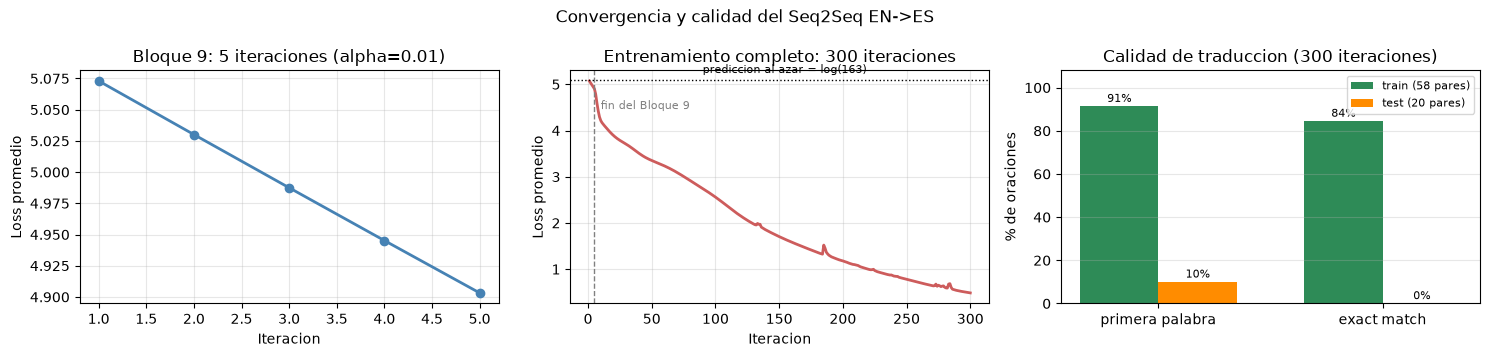

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

# Izquierda: las 5 iteraciones del Bloque 9 (verificacion del backward)
axes[0].plot(range(1, 6), losses_train, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Iteracion'); axes[0].set_ylabel('Loss promedio')
axes[0].set_title('Bloque 9: 5 iteraciones (alpha=0.01)')
axes[0].grid(True, alpha=0.3)

# Centro: las 300 iteraciones completas
axes[1].plot(range(1, len(losses_full) + 1), losses_full, color='indianred', linewidth=2)
axes[1].axvline(5, color='gray', linestyle='--', linewidth=1)
axes[1].text(10, max(losses_full) * 0.88, 'fin del Bloque 9', fontsize=8, color='gray')
axes[1].axhline(float(np.log(tgt_V)), color='black', linestyle=':', linewidth=1)
axes[1].text(90, float(np.log(tgt_V)) + 0.15, 'prediccion al azar = log(163)',
             fontsize=8, color='black')
axes[1].set_xlabel('Iteracion'); axes[1].set_ylabel('Loss promedio')
axes[1].set_title('Entrenamiento completo: 300 iteraciones')
axes[1].grid(True, alpha=0.3)

# Derecha: calidad real de la traduccion, train vs test
def metricas(data):
    primera = exacta = 0
    for s, t in data:
        pred = traducir(s)
        if pred and pred.split()[0] == t.split()[0]: primera += 1
        if pred == t: exacta += 1
    return primera / len(data) * 100, exacta / len(data) * 100

m_train = metricas(TRAIN_DATA); m_test = metricas(TEST_DATA)
x = np.arange(2); ancho = 0.35
axes[2].bar(x - ancho/2, m_train, ancho, label='train (58 pares)', color='seagreen')
axes[2].bar(x + ancho/2, m_test,  ancho, label='test (20 pares)',  color='darkorange')
for i, (a, b) in enumerate(zip(m_train, m_test)):
    axes[2].text(i - ancho/2, a + 2, f'{a:.0f}%', ha='center', fontsize=8)
    axes[2].text(i + ancho/2, b + 2, f'{b:.0f}%', ha='center', fontsize=8)
axes[2].set_xticks(x); axes[2].set_xticklabels(['primera palabra', 'exact match'])
axes[2].set_ylabel('% de oraciones'); axes[2].set_ylim(0, 108)
axes[2].set_title('Calidad de traduccion (300 iteraciones)')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Convergencia y calidad del Seq2Seq EN->ES')
plt.tight_layout()
plt.savefig('convergencia_seq2seq.png', dpi=110, bbox_inches='tight')
plt.show()

---
## Bloque 12: Preguntas de analisis

---

### Pregunta 1 (35 pts)

El corpus tiene tres tipos de pares: traducciones mas cortas en espanol (elision del sujeto: *she sings well* -> *canta bien*), mas largas (perifrasis: *the cat sleeps* -> *el gato esta durmiendo*), y del mismo largo.

a) Durante el entrenamiento con teacher forcing, el decoder para el par (*she sings well*, *canta bien*) corre 2 pasos y para (*the cat sleeps*, *el gato esta durmiendo*) corre 4 pasos. Explique como afecta esa diferencia al gradiente que llega a los pesos del encoder en cada caso. Use la formula del recorrido del gradiente $S + T$ pasos.

b) Durante la inferencia greedy, el decoder debe aprender a generar EOS en el momento correcto. Para un par donde el espanol es mas corto que el ingles, ¿que debe haber aprendido el modelo para detener la generacion antes de que el decoder produzca tantos tokens como el encoder proceso? ¿Que informacion del encoder codifica esa senal de parada?

c) Si ordenara el corpus de entrenamiento de menor a mayor largo de la secuencia de salida (curriculum learning), ¿esperaria que el modelo convergiera mas rapido, mas lento, o igual? Justifique en terminos del gradiente y del proceso de aprendizaje.

**Su respuesta a la Pregunta 1:**

### a)

El gradiente que llega a los pesos del encoder recorre una cadena de $S + T$ pasos: primero atraviesa los $S$ pasos del decoder (desde la perdida hasta $h_0^{dec} = \mathbf{c}$) y luego los $T$ pasos del encoder.

* (*she sings well* → *canta bien*): $T=3$, $S=3$ (`canta`, `bien`, `<EOS>`) → 6 pasos.
* (*the cat sleeps* → *el gato esta durmiendo*): $T=3$, $S=5$ → 8 pasos.

Mientras más largo es ese recorrido, más se atenúa el gradiente, porque en cada paso se multiplica por el jacobiano de la celda LSTM, y por el camino de la memoria el factor dominante es la puerta de olvido $\partial c_t/\partial c_{t-1} = f_t \in (0,1)$. Con inicialización aleatoria y sesgos en cero, $f_t \approx 0.5$, así que la magnitud que llega al encoder escala aproximadamente como

$$\prod f \approx 0.5^{S+T}.$$

Dos pasos extra significan casi cuatro veces menos señal para el encoder en el par con perífrasis que en el par con elisión.

A eso se suma la dilución por el promedio: como la pérdida se calcula como

$$L=\frac{1}{S}\sum_s L_s,$$

cada paso aporta $\frac{1}{S}(\hat y_s - \mathbf{1})$. Cuando la salida es más larga, cada término individual pesa menos ($1/5$ en lugar de $1/3$), aunque hay más términos sumándose en $\partial L/\partial \mathbf{c}$: los pares largos entregan un gradiente promediado sobre más evidencia (menos varianza) pero más atenuado, y los cortos uno más fuerte y más ruidoso.

En la práctica, los pares con español más corto entrenan al encoder con más fuerza por actualización que los de perífrasis, aunque estos últimos traigan más información sobre la salida, es un sesgo del entrenamiento, no un error de implementación.

### b)

El modelo tiene que aprender que `<EOS>` es la palabra correcta en el paso $S$, ni antes ni después. Como el decoder es autoregresivo y su única fuente de información sobre la entrada es $\mathbf{c} = h_T^{enc}$, esa señal de parada se arma con dos ingredientes.

Por un lado, lo que codifica el encoder: $\mathbf{c}$ no guarda solo el significado, también guarda propiedades sintácticas que correlacionan con el largo de la salida. En este corpus, un pronombre explícito (`she`, `he`, `i`) predice elisión del sujeto en español y una salida más corta; `the` + sujeto nominal (`the cat sleeps`) predice perífrasis progresiva y una salida más larga. El encoder aprende a separar esas dos familias en el espacio de contexto porque hacerlo reduce la pérdida justo en el paso de `<EOS>`.

Por otro lado, lo que cuenta el decoder: el estado $h_s^{dec}$ evoluciona paso a paso y, junto con $\mathbf{c}$, funciona como un contador implícito de cuántos tokens lleva generados. La combinación "el contexto dice que esta oración es de 2 palabras" + "el estado dice que ya llevo 2" es lo que hace que $W_{out} h_s^{dec}$ ponga la masa de probabilidad en `<EOS>`.

Nada de esto es explícito, no hay ninguna variable de largo en la arquitectura. El largo es una propiedad emergente codificada en 32 números reales, y por eso generar `<EOS>` en el momento correcto es de lo último que aprende bien un seq2seq sin atención.

### c)

Esperaría que convergiera **más rápido al inicio**, pero con una salvedad importante para este corpus en particular.

A favor: las oraciones cortas tienen un recorrido $S+T$ menor, así que el gradiente llega con menos atenuación al encoder y el modelo aprende primero lo fácil y más frecuente (emitir `<EOS>`, las palabras comunes), lo que da un buen punto de partida para las oraciones largas.

En contra, y es el punto crítico aquí: el largo de salida está correlacionado con el tipo de oración. Ordenar por largo equivale a agrupar primero todos los pares con elisión y al final todos los de `esta + gerundio`. Sin barajar, el modelo pasaría las últimas actualizaciones de cada iteración viendo solo perífrasis y tendería a sobreajustar el patrón más reciente — predeciría `el ... esta ...` incluso para `she sings well`.


---
### Pregunta 2 (35 pts)

a) En el Bloque 10 evalua el porcentaje de oraciones donde la primera palabra generada es correcta. Explique por que esa metrica es mas informativa que la loss de entrenamiento para evaluar la calidad de un sistema de traduccion, y cuales son sus limitaciones.

b) El Bloque 7 muestra que solo una fraccion de las columnas de `E_enc` tienen gradiente no cero en cada actualizacion. Con 78 pares de entrenamiento y 158 palabras en el vocabulario ingles, estime cuantas palabras del vocabulario podrian nunca recibir gradiente durante 5 iteraciones, y que implicacion tiene eso para la representacion de esas palabras.

c) Si quisiera extender este modelo para traducir del espanol al ingles ademas de del ingles al espanol (un solo modelo bidireccional), describa dos enfoques arquitectonicos distintos y justifique cual de los dos preserva mejor la informacion aprendida en este laboratorio.

Su respuesta a la Pregunta 2:

### a)

La metrica de primera palabra correcta es mas informativa porque evalua el comportamiento del modelo en la tarea real, sin ayuda. La loss de entrenamiento se calcula con teacher forcing: en cada paso el decoder recibe la palabra correcta anterior, aunque el mismo hubiera predicho otra cosa. Mide que tan bien predice el siguiente token dado un prefijo perfecto, no la traduccion real.

La primera palabra, en cambio, se mide en decodificacion greedy sobre el conjunto de prueba, generando de verdad y sobre oraciones que el modelo nunca vio. Es tambien el primer punto donde aparece el exposure bias: si el primer token sale mal, todo lo que sigue se arrastra, porque ese token alimenta el paso siguiente. Por eso la loss puede seguir bajando mientras la traduccion generada sigue siendo mala.

Sus limitaciones son varias. Solo evalua un token de toda la oracion, asi que un modelo que acierta la primera palabra y despues genera ruido puntua igual que uno que traduce bien. Es binaria, sin credito parcial: no distingue un sinonimo valido de un error total. Es explotable por frecuencia, porque en este corpus el primer token esta muy determinado por el sujeto ingles, asi que memorizar pares como they -> ...n o the -> el da buen puntaje sin entender nada. Y no mide longitud, fluidez, orden ni concordancia, que es justo lo que la arquitectura encoder-decoder deberia resolver. Con solo 20 pares de prueba, ademas, cada acierto vale 5 puntos porcentuales, asi que el margen de error es enorme. Lo razonable seria complementarla con exact-match de la oracion completa, accuracy por token y algo tipo BLEU.

### b)

En cada actualizacion solo reciben gradiente las columnas de E_enc correspondientes a las palabras que aparecen en el lote de entrenamiento. Con 58 pares de entrenamiento y un vocabulario ingles de 158 entradas, de esas columnas se actualizan unas 123, es decir que unas 35 palabras (cerca del 22%) nunca reciben gradiente.

Esto no se arregla con mas iteraciones: las 5 pasadas recorren siempre el mismo conjunto de entrenamiento, asi que el grupo de columnas que se actualiza es identico en cada una. Esas 35 palabras se quedan exactamente con su inicializacion aleatoria, que no es una mala representacion sino puro ruido sin relacion con el significado. Como varias de ellas aparecen en el conjunto de prueba, al traducir esas oraciones el encoder consume vectores arbitrarios y produce un contexto arbitrario: parte de los errores de traduccion no son falta de entrenamiento, son vocabulario que el modelo nunca vio actualizarse. Es la razon por la que en la practica se usan embeddings preentrenados, tokenizacion por subpalabras o entrenamiento explicito de un token UNK.

### c)

Dos enfoques distintos para hacerlo bidireccional:

Enfoque 1, un solo modelo con token de idioma. Se construye un vocabulario conjunto ingles-espanol, con una matriz de embeddings compartida, un solo encoder y un solo decoder, y la direccion se indica anteponiendo una etiqueta a la entrada, algo como <2es> i love you o <2en> te amo. A favor tiene la mitad de parametros y que las dos direcciones se refuerzan entre si porque el encoder ve el doble de datos. En contra, obliga a reconstruir el vocabulario y reinicializar las matrices de embeddings, porque los indices cambian, asi que los pesos entrenados en este laboratorio dejan de servir tal cual.

Enfoque 2, dos encoders y dos decoders sobre un espacio de contexto compartido. Se entrena un encoder y decoder ingles-espanol y otro espanol-ingles, forzando a que ambos encoders proyecten a un espacio de contexto comun. A favor, el encoder y decoder de este laboratorio se reutilizan directamente sin tocar vocabularios ni indices, solo hay que entrenar los dos modulos nuevos. En contra, duplica los parametros y, sin un termino de perdida que alinee los dos espacios latentes, estos pueden terminar sin compartir nada realmente.

El enfoque que mejor preserva lo aprendido aqui es el segundo: los vocabularios y las matrices ya entrenadas siguen siendo validos y solo se agregan modulos nuevos, mientras que el primero exige reindexar todo y entrenar de nuevo desde cero. El primer enfoque es mejor a escala, con millones de pares y vocabulario compartido por subpalabras, pero como continuacion directa de este modelo el modular es el que conserva lo ya aprendido.


---
### Pregunta 3 (30 pts)

a) Si convirtiera este seq2seq en un autoencoder para comprimir oraciones en espanol, describa exactamente los tres cambios de codigo necesarios en el Bloque 9. Sea especifico sobre la funcion de perdida, los tokens de entrada y salida del decoder, y los vocabularios.

b) En el seq2seq, el backward fluye desde la perdida hasta `E_enc` a traves de $S + T$ pasos. En un autoencoder sobre el mismo corpus, ¿ese recorrido seria el mismo, mas corto o mas largo? Justifique considerando que las oraciones de entrada y salida son iguales.

c) El vector de contexto $\mathbf{c}$ de dimension 32 debe comprimir toda la informacion de la entrada. Para las oraciones mas largas del corpus (*nosotros nos reunimos cada semana*, 5 palabras), ¿es suficiente esa dimension? ¿Que pasaria con la calidad de la reconstruccion si redujera la dimension a 2?

Su respuesta a la Pregunta 3:

### a)

Los tres cambios principales en el Bloque 9 serian:

Usar un solo vocabulario en espanol. Como la entrada y la salida son el mismo idioma, el encoder y el decoder dejan de necesitar el vocabulario ingles y pasan a operar sobre el vocabulario espanol. Lo natural es que compartan una sola matriz de embeddings (E_enc = E_dec = E_es), porque ambos indexan las mismas palabras y asi el gradiente de las dos ramas se acumula en la misma columna en lugar de aprender dos representaciones separadas para lo mismo.

Cambiar los datos de entrenamiento. Los pares dejan de ser (ingles, espanol) y pasan a ser (espanol, espanol): se ignora la columna en ingles y el encoder recibe la oracion en espanol sin <SOS>/<EOS>. El decoder sigue usando teacher forcing igual que antes, solo que ahora entra <SOS> seguido de la oracion y el objetivo es predecir esa misma oracion terminando en <EOS>. Es decir, el objetivo del paso s es reproducir la palabra s de la misma oracion que leyo el encoder, no su traduccion.

Mantener la misma funcion de perdida. La salida sigue siendo una distribucion sobre el vocabulario en cada paso, asi que la entropia cruzada categorica no cambia. Lo unico que cambia es que ahora el objetivo es reconstruir la oracion de entrada en lugar de traducirla. Para que sea un autoencoder compresivo de verdad, ademas conviene reducir la dimension del vector de contexto, porque con d_hid = 32 y oraciones de 3 palabras el modelo tiene capacidad de sobra y aprenderia la identidad sin comprimir nada.

### b)

El gradiente sigue recorriendo $S + T$ pasos, con $T$ el largo de la entrada y $S$ el largo de la salida mas el `<EOS>`. En el seq2seq esos dos largos son distintos porque son idiomas distintos; en el autoencoder son la misma oracion, asi que $S = T_{es} + 1$, y el recorrido queda

$$T_{es} + (T_{es} + 1) = 2T_{es} + 1$$

En este corpus el espanol promedia unas 3 palabras y el ingles unas 3.5, asi que en el seq2seq el recorrido promedio es de unos 7.5 pasos y en el autoencoder de unos 7 pasos: ligeramente mas corto, porque el espanol de este corpus tiende a ser mas breve que el ingles por la elision del sujeto. No es una propiedad general de los autoencoders, es un efecto de este corpus en particular; lo que si es general es que en el autoencoder el recorrido queda balanceado ($T$ y $S$ son iguales salvo el `<EOS>`), mientras que en traduccion puede estar bastante desbalanceado, que es justo lo que hacia que el encoder recibiera gradientes de magnitud distinta segun el par en la pregunta 1a.

### c)

Con 32 dimensiones alcanza de sobra para este corpus. Son apenas 78 oraciones de a lo mucho 5 palabras sobre un vocabulario de unas 160 entradas, y un vector de 32 numeros reales tiene capacidad de informacion muy superior a lo que hay que guardar ahi. El cuello de botella real no esta en la dimension sino en la dinamica del LSTM, en si logra mantener la informacion del primer token despues de varias puertas de olvido multiplicativas.

Con 2 dimensiones la reconstruccion se degrada bastante. En teoria existe una forma de meter 78 oraciones distintas en un espacio de 2 numeros, pero esa funcion tendria fronteras muy finas y el descenso de gradiente no la encuentra, porque el optimizador busca representaciones suaves donde puntos cercanos decodifiquen a salidas parecidas. En la practica el modelo terminaria agrupando oraciones parecidas (las que empiezan con el, con la, las que usan esta + gerundio) y, ante un vector ambiguo, el decoder generaria la oracion mas probable del grupo en vez de la oracion exacta: la estructura general saldria bien pero las palabras de contenido, mal. La curva de perdida mostraria eso mismo, bajando rapido al principio y despues estancandose en una meseta que no se rompe con mas iteraciones, porque el limite ahi es de capacidad y no de entrenamiento.


---
## Bloque 13: Nota automatica sobre la seccion de codigo

In [25]:
_PUNTOS = {
    'b2': ('Bloque 2:  Encoder forward',           18),
    'b4': ('Bloque 4:  Perdida CE categorica',       8),
    'b5': ('Bloque 5:  Backward decoder',           14),
    'b6': ('Bloque 6:  Backward encoder',           10),
    'b7': ('Bloque 7:  dE completa vs diccionario',  5),
    'b8': ('Bloque 8:  Actualizacion de pesos',      2),
    'b9': ('Bloque 9:  Convergencia 5 iteraciones',  3),
}
_TOTAL = 60
print('=' * 62)
print('  NOTA AUTOMATICA - SECCION DE CODIGO')
print('=' * 62)
_obtenido = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    val = _resultados.get(key, False)
    pts = pts_max if val is True else 0
    _obtenido += pts
    print(f'  {"CORRECTO" if val is True else "PENDIENTE":10s} | {nombre:38s} | {pts:2d}/{pts_max} pts')
if isinstance(_resultados.get('b10'), float):
    print(f'  INFO       | B10 primera palabra test: {_resultados["b10"]:.1f}%')
print('-' * 62)
print(f'  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos')
print('  Pendiente manual:')
print('    Bloque 12 preguntas : __/25 pts')
print('    Comentarios codigo  : __/15 pts')
print('-' * 62)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('=' * 62)

  NOTA AUTOMATICA - SECCION DE CODIGO
  CORRECTO   | Bloque 2:  Encoder forward             | 18/18 pts
  CORRECTO   | Bloque 4:  Perdida CE categorica       |  8/8 pts
  CORRECTO   | Bloque 5:  Backward decoder            | 14/14 pts
  CORRECTO   | Bloque 6:  Backward encoder            | 10/10 pts
  CORRECTO   | Bloque 7:  dE completa vs diccionario  |  5/5 pts
  CORRECTO   | Bloque 8:  Actualizacion de pesos      |  2/2 pts
  CORRECTO   | Bloque 9:  Convergencia 5 iteraciones  |  3/3 pts
  INFO       | B10 primera palabra test: 10.0%
--------------------------------------------------------------
  Subtotal codigo:   60/60 puntos
  Pendiente manual:
    Bloque 12 preguntas : __/25 pts
    Comentarios codigo  : __/15 pts
--------------------------------------------------------------
  TOTAL FINAL (sobre 100): __/100 pts
